In [6]:
import pandas as pd
import numpy as np

data = pd.read_pickle('../data/merged_clean.pkl')
print("Shape:", data.shape)

label_col = "Label"
y = data[label_col]
X = data.drop(columns=[label_col])

print("\nClasses:", y.nunique())
print(y.value_counts())

Shape: (2520798, 79)

Classes: 15
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [7]:
# Columns with a single constant value tell the model nothing
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
print("Constant columns:", constant_cols)

# CICIDS2017 ships a duplicated column name
dupe_cols = X.columns[X.columns.duplicated()].tolist()
print("Duplicate column names:", dupe_cols)

X = X.loc[:, ~X.columns.duplicated()]
X = X.drop(columns=constant_cols)
print("\nRemaining features:", X.shape[1])

Constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Duplicate column names: []

Remaining features: 70


In [8]:
print(X.columns.tolist())


['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packe

In [9]:
# Destination Port is dropped: it maps almost 1:1 onto attack type in
# CICIDS2017 (21 -> FTP-Patator, 22 -> SSH-Patator, 80 -> web attacks),
# so retaining it lets a model memorise the port rather than learn flow
# behaviour. Excluding it gives a stricter test of detection quality.
X = X.drop(columns=['Destination Port'])
print("Features:", X.shape[1])

Features: 69


In [10]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
import time

# Rank on a stratified subsample: mutual information on 2.5M rows is
# prohibitively slow, and the ranking is stable at this sample size.
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=200_000, stratify=y, random_state=42
)

t = time.time()
mi = mutual_info_classif(X_sample, y_sample, random_state=42)
print(f"Computed in {time.time()-t:.1f}s")

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_scores.head(25))

Computed in 195.2s
Average Packet Size            0.556713
Packet Length Std              0.530080
Packet Length Variance         0.528261
Packet Length Mean             0.527432
Total Length of Bwd Packets    0.489983
Subflow Bwd Bytes              0.489833
Avg Bwd Segment Size           0.484420
Bwd Packet Length Mean         0.484018
Total Length of Fwd Packets    0.465631
Subflow Fwd Bytes              0.463334
Init_Win_bytes_backward        0.446648
Bwd Packet Length Max          0.446446
Max Packet Length              0.439420
Fwd Packet Length Max          0.432872
Init_Win_bytes_forward         0.431086
Fwd IAT Max                    0.416041
Flow IAT Max                   0.405859
Fwd IAT Total                  0.396366
Fwd Header Length.1            0.394615
Fwd Header Length              0.394029
Flow Duration                  0.385875
Fwd Packet Length Mean         0.379570
Fwd IAT Mean                   0.378353
Avg Fwd Segment Size           0.377712
Bwd Packet Length Std

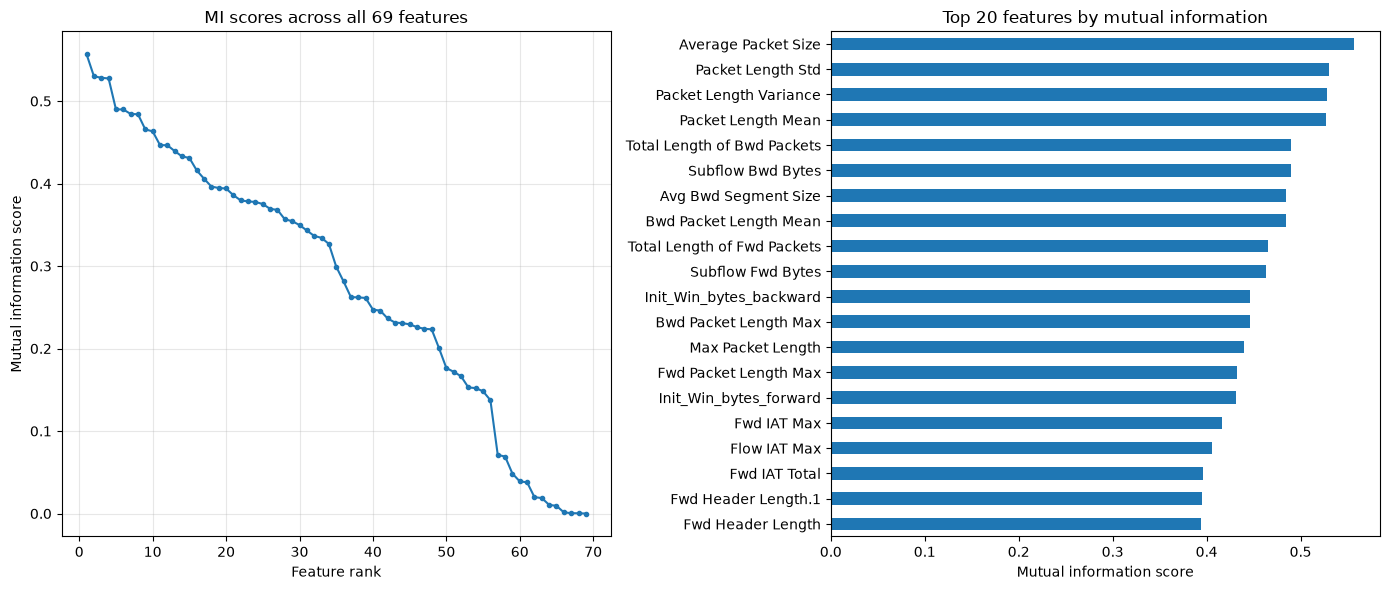

In [11]:
mi_scores.to_csv('../results/mutual_information_scores.csv', header=['mi_score'])

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full curve - to find the elbow
axes[0].plot(range(1, len(mi_scores)+1), mi_scores.values, marker='o', markersize=3)
axes[0].set_xlabel('Feature rank')
axes[0].set_ylabel('Mutual information score')
axes[0].set_title('MI scores across all 69 features')
axes[0].grid(alpha=0.3)

# Top 20 - for the dissertation
mi_scores.head(20).sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Mutual information score')
axes[1].set_title('Top 20 features by mutual information')

plt.tight_layout()
plt.savefig('../figures/mutual_information.png', dpi=200)
plt.show()

In [12]:
X = X.drop(columns=['Fwd Header Length.1'])
mi_scores = mi_scores.drop('Fwd Header Length.1')
print("Features:", X.shape[1])

Features: 68


In [13]:
import json

feature_sets = {
    'top10': mi_scores.head(10).index.tolist(),
    'top20': mi_scores.head(20).index.tolist(),
    'top30': mi_scores.head(30).index.tolist(),
    'top49': mi_scores.head(49).index.tolist(),
    'all':   X.columns.tolist(),
}

with open('../results/feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=2)

for k, v in feature_sets.items():
    print(f"{k}: {len(v)} features")

top10: 10 features
top20: 20 features
top30: 30 features
top49: 49 features
all: 68 features


In [15]:
# Merge the three web-attack variants into one class
y = y.replace({
    'Web Attack - Brute Force': 'Web Attack',
    'Web Attack - XSS': 'Web Attack',
    'Web Attack - Sql Injection': 'Web Attack',
})

# Exclude classes too rare to train or evaluate on.
# Heartbleed (11) and Infiltration (36) cannot support a stratified
# train/test split; they are reported as a known limitation instead.
rare = ['Heartbleed', 'Infiltration']
mask = ~y.isin(rare)
X, y = X[mask], y[mask]

print(y.value_counts())
print("\nClasses:", y.nunique(), " Rows:", len(y))

Label
BENIGN              2095057
DoS Hulk             172846
DDoS                 128014
PortScan              90694
DoS GoldenEye         10286
FTP-Patator            5931
DoS slowloris          5385
DoS Slowhttptest       5228
SSH-Patator            3219
Web Attack             2143
Bot                    1948
Name: count, dtype: int64

Classes: 11  Rows: 2520751


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import time

# 300k stratified subsample: keeps this comparison tractable.
# The final evaluation (notebook 05) uses the full dataset.
X_sub, _, y_sub, _ = train_test_split(
    X, y, train_size=300_000, stratify=y, random_state=42
)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=42
)

rows = []
for name, feats in feature_sets.items():
    Xtr, Xte = X_tr[feats], X_te[feats]

    # Decision Tree (no scaling needed)
    t = time.time()
    dt = DecisionTreeClassifier(random_state=42).fit(Xtr, y_tr)
    dt_time = time.time() - t
    dt_f1 = f1_score(y_te, dt.predict(Xte), average='macro')

    # Logistic Regression (needs scaling)
    sc = StandardScaler().fit(Xtr)
    t = time.time()
    lr = LogisticRegression(max_iter=1000, random_state=42).fit(sc.transform(Xtr), y_tr)
    lr_time = time.time() - t
    lr_f1 = f1_score(y_te, lr.predict(sc.transform(Xte)), average='macro')

    rows.append({'features': len(feats), 'set': name,
                 'dt_macro_f1': dt_f1, 'dt_train_s': dt_time,
                 'lr_macro_f1': lr_f1, 'lr_train_s': lr_time})
    print(f"{name:6s} ({len(feats):2d}) DT F1={dt_f1:.4f} ({dt_time:.1f}s)  LR F1={lr_f1:.4f} ({lr_time:.1f}s)")

results = pd.DataFrame(rows)
results.to_csv('../results/feature_subset_comparison.csv', index=False)
results

top10  (10) DT F1=0.8083 (4.7s)  LR F1=0.2490 (36.2s)
top20  (20) DT F1=0.9446 (8.6s)  LR F1=0.3463 (35.0s)
top30  (30) DT F1=0.9418 (13.5s)  LR F1=0.4256 (43.1s)
top49  (49) DT F1=0.9495 (22.9s)  LR F1=0.5959 (49.4s)
all    (68) DT F1=0.9581 (24.3s)  LR F1=0.7381 (54.6s)


,features,set,dt_macro_f1,dt_train_s,lr_macro_f1,lr_train_s
0,10,top10,0.808288,4.714057,0.248955,36.159443
1,20,top20,0.944634,8.555202,0.346349,35.042575
2,30,top30,0.941768,13.547471,0.425564,43.054996
3,49,top49,0.949527,22.942353,0.595920,49.383612
4,68,all,0.958057,24.304996,0.738146,54.642125


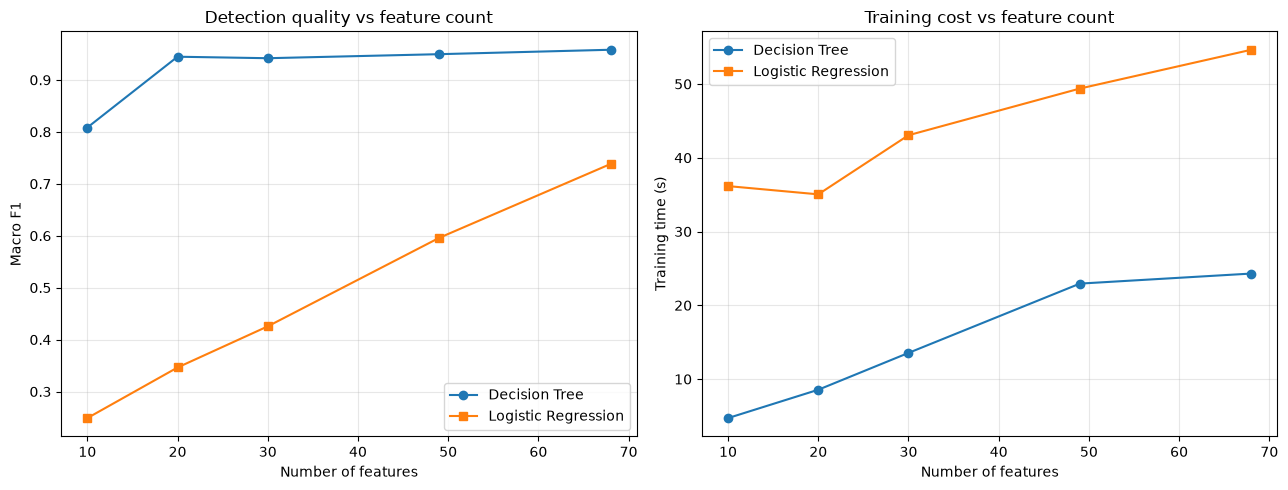

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(results['features'], results['dt_macro_f1'], marker='o', label='Decision Tree')
axes[0].plot(results['features'], results['lr_macro_f1'], marker='s', label='Logistic Regression')
axes[0].set_xlabel('Number of features'); axes[0].set_ylabel('Macro F1')
axes[0].set_title('Detection quality vs feature count'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(results['features'], results['dt_train_s'], marker='o', label='Decision Tree')
axes[1].plot(results['features'], results['lr_train_s'], marker='s', label='Logistic Regression')
axes[1].set_xlabel('Number of features'); axes[1].set_ylabel('Training time (s)')
axes[1].set_title('Training cost vs feature count'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_subset_tradeoff.png', dpi=200)
plt.show()